# E01: 
train a trigram language model, i.e. take two characters as an input to predict the 3rd one. Feel free to use either counting or a neural net. Evaluate the loss; Did it improve over a bigram model?

In [ ]:
import torch

### Data inspection and experimenation
The following is experimentation to reach the solution, to jump to full finalised clean version,
[click here](#final-solution)

In [2]:
words = open("names.txt", 'r').read().splitlines()

In [3]:
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [4]:
len(words)

32033

In [5]:
min(words, key=len), len(min(words, key=len))

('an', 2)

In [6]:
max(words, key=len), max(min(words, key=len))

('muhammadibrahim', 'n')

In [296]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.']=0

Goal: Make a dictionary having int labelling of characters from a to z and '.' as well as all labelling of all possible two character combinations.

In [8]:
combinations = []
for word in words:
    chs = ['.'] + list(word) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        combination = ch1+ch2
        combinations.append(combination)
all_combinations = sorted(list(set(combinations)))
all_combinations[:5]

['.a', '.b', '.c', '.d', '.e']

In [9]:
chars = sorted(list(set(''.join(words)))) # a, b, c, d, .... x, y, z
all_keys = chars + all_combinations
# all_keys

In [10]:
len(all_keys)

653

In [11]:
print(f"Total combinations possible: 27*27 = {27*27} \n" 
      f"Total combinations obtained through available names in data: {len(all_combinations)}")

Total combinations possible: 27*27 = 729 
Total combinations obtained through available names in data: 627


In [12]:
# Create dictionary
stoi = {s:i+1 for i, s in enumerate(all_keys)}
stoi['.']=0
stoi['.'], stoi['z'], stoi['s'], stoi['sa']

(0, 26, 19, 471)

In [13]:
print(f"Length of dictionary: 627 combinations + 27 characters = {len(stoi)}")

Length of dictionary: 627 combinations + 27 characters = 654


Goal: Prepare training data xs and test data ys

In [14]:
xs, ys = [], []
for w in words[:1]:
    chs = ['.','.'] + list(w) + ['.']  # eg ['.', 'e', 'm', 'm', 'a', '.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ch12 = ch1+ch2
        idx12 = stoi[ch12]
        idx3 = stoi[ch3]
        xs.append(idx12)
        ys.append(idx3)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
xs, ys # eg ['.', 'e', 'm', 'm', 'a', '.'] = [0, 5, 13, 13, 1, 0] so m=13

(tensor([ 31, 156, 346, 335]), tensor([13, 13,  1,  0]))

In [15]:
stoi['m']

13

Goal: Encode training examples

In [16]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=654).float()
xenc.dtype, xenc.shape

(torch.float32, torch.Size([4, 654]))

In [17]:
import matplotlib.pyplot as plt

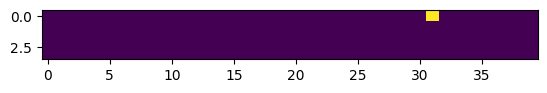

In [18]:
plt.imshow(xenc[:,:40])

Goal: Create weights, do forward pass and backward pass

In [19]:
g = torch.Generator().manual_seed(312317)
W = torch.randn((654, 27), generator=g, requires_grad=True)

In [20]:
print(f"Number of parameters in neural network = {W.numel()}")
print(f"Shape of W: {W.shape}")

Number of parameters in neural network = 17658
Shape of W: torch.Size([654, 27])


In [21]:
#----------Forward pass------------
logits = xenc @ W # 4,654 @ 654, 27 = 4,27

#Softmax
counts = logits.exp() 
probs = logits/logits.sum(1, keepdim=True) 
loss = -probs[torch.arange(4), ys].log().mean()
# loss_fn = nn.CrossEntropyLoss(logits, ys)


In [22]:
logits.sum(1, keepdim=True).shape, logits.sum(1).shape
# If we forget keepdim=True, then broadcasting would internally convert torch.size([4]) to torch.size([1, 4]) 
# instead of torch.size([4, 1]) thus causing everything after it to go wrong

(torch.Size([4, 1]), torch.Size([4]))

In [23]:
loss = -probs[torch.arange(4), ys].log().mean()
loss
#-probs[torch.arange(4), ys].log() :  negative log likelihood loss
# .mean for average loss fore each class

tensor(4.2690, grad_fn=<NegBackward0>)

In [24]:
ys

tensor([13, 13,  1,  0])

In [25]:
probs

tensor([[0.0346, 0.0208, 0.0082, 0.0444, 0.0046, 0.0089, 0.0064, 0.0175, 0.0128,
         0.0027, 0.0249, 0.1339, 0.0875, 0.0100, 0.0485, 0.0221, 0.0580, 0.0074,
         0.2635, 0.0090, 0.0278, 0.0268, 0.0172, 0.0672, 0.0149, 0.0124, 0.0083],
        [0.0174, 0.1579, 0.0297, 0.0090, 0.0259, 0.0407, 0.0725, 0.0112, 0.0334,
         0.1011, 0.0346, 0.0170, 0.0851, 0.0362, 0.0091, 0.0077, 0.0091, 0.0140,
         0.0493, 0.0126, 0.0215, 0.0348, 0.1033, 0.0112, 0.0414, 0.0035, 0.0111],
        [0.1116, 0.0194, 0.0506, 0.0144, 0.0318, 0.0361, 0.0139, 0.0087, 0.0868,
         0.0565, 0.0196, 0.0173, 0.0497, 0.0347, 0.0114, 0.0415, 0.0195, 0.0439,
         0.0224, 0.0148, 0.0847, 0.0053, 0.1228, 0.0171, 0.0260, 0.0185, 0.0212],
        [0.0054, 0.0417, 0.2488, 0.0058, 0.0103, 0.1365, 0.0075, 0.0181, 0.0063,
         0.0793, 0.0040, 0.0256, 0.0720, 0.0614, 0.0076, 0.0060, 0.0120, 0.0258,
         0.0094, 0.0025, 0.0236, 0.0217, 0.0671, 0.0333, 0.0141, 0.0493, 0.0048]],
       grad_fn=<DivBack

<a id="Final Solution:"></a>



<a id="final-solution"></a>

### Final Solution

In [208]:
# Load data
words = open("names.txt", 'r').read().splitlines()

# Inspect
# (check experimentation section at the beginning)

In [209]:
chars = ['.'] + sorted(list(set(''.join(words)))) # ., a, b, c, d, .... x, y, z
len(chars)

27

In [292]:
# Create dictionary for mapping single char to its ID
stoi = {s:i for i, s in enumerate(chars)}

# Create another dictionary for reverse mapping
itos = {i:s for i, s in enumerate(stoi.items())}

# Check if its correct
stoi['.'], stoi['a'], itos[1][0]

(0, 1, 'a')

In [294]:
# Get all 27*27 combinations
all_combinations = [a + b for a in chars for b in chars]

# Create dictionary for mapping combination to its ID
ctoi={c:i for i,c in enumerate(all_combinations)}

# Create another dictionary for reverse mapping
itoc={i:c for i,c in enumerate(ctoi.items())}

# Check if its correct
len(ctoi), ctoi['..'], itoc[1][0]

(729, 0, '.a')

**Note:** A universal dictionary (`combinations + chars`) would not work in this case because the character IDs would fall in the range **729–755**, while the output classes are expected to be in the range **0–26**.

Doing it the other way around would not work either, because the combination IDs would fall in the range **27–755**, while `one_hot` for the input expects IDs in the range **0–728** when `num_classes=729`.

Therefore, separate dictionaries are needed:
- `ctoi` → character → IDs `0–26`
- `stoi` → combination → IDs `0–728`


In [227]:
# Creating the dataset
xs, ys = [], []
for w in words:
    chs = ['.','.'] + list(w) + ['.']  # eg ['.', 'e', 'm', 'm', 'a', '.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ch12 = ch1+ch2
        idx12 = ctoi[ch12]
        idx3 = stoi[ch3]
        xs.append(idx12)
        ys.append(idx3)

# Converting dataset into tensor
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.numel()
xs, ys, num # eg ['.', 'e', 'm', 'm', 'a', '.'] = [0, 5, 13, 13, 1, 0] so m=13

(tensor([  0,   5, 148,  ..., 727, 701, 726]),
 tensor([ 5, 13, 13,  ..., 26, 24,  0]),
 228146)

In [228]:
# Setting up generator and creating weights
g = torch.Generator().manual_seed(312317)
W = torch.randn((729, 27), generator=g, requires_grad=True)

In [229]:
# Training loop
for i in range(50):
    #----------Forward pass------------
    xenc = F.one_hot(xs, num_classes=len(all_combinations)).float() #729
    logits = xenc @ W # (228146, 729) @ (729, 27) = (4,27)

    counts = logits.exp() 
    probs = logits/logits.sum(1, keepdim=True) 
    loss = -probs[torch.arange(num), ys].log().mean()
    print(loss.item())
    
    #-----------Backward pass--------------
    W.grad = None # set weights to zero
    loss.backward()

    #------------Update weights--------------
    W.data += -70 * W.grad

3.7226085662841797
3.56234073638916
3.4743316173553467
3.4020345211029053
3.3388397693634033
3.2824339866638184
3.2318317890167236
3.186340093612671
3.1453230381011963
3.1081879138946533
3.0744049549102783
3.0435211658477783
3.0151586532592773
2.989006519317627
2.9648072719573975
2.942347526550293
2.921443462371826
2.9019360542297363
2.88368558883667
2.866567373275757
2.8504703044891357
2.835296630859375
2.8209588527679443
2.807379961013794
2.79449200630188
2.7822351455688477
2.7705564498901367
2.7594079971313477
2.7487480640411377
2.738539695739746
2.7287492752075195
2.7193474769592285
2.710306406021118
2.7016026973724365
2.6932156085968018
2.685124397277832
2.677311658859253
2.6697614192962646
2.662459135055542
2.655390739440918
2.6485447883605957
2.641909122467041
2.63547420501709
2.629229784011841
2.623167037963867
2.6172778606414795
2.6115543842315674
2.605989694595337
2.600576400756836
2.595308542251587


In [287]:
# Generating names
for i in range(10):
    out = [] # for storing the output
    context = ['.', '.'] # for triggering the model to start outputting characters to form a name
    
    while True:
        pair = context[0] + context[1]
        ix = ctoi[pair]
    
        xenc = F.one_hot(torch.tensor([ix]), num_classes=729).float() 
        logits = xenc @ W
        counts = logits.exp()
        p = counts / counts.sum(1, keepdim=True)

        # Randomly draw one index from the 27 indices, using the values in p as the sampling probabilities.
        # idx with highest probability has higher chances, but its not guaranteed
        next_ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    
        next_char = itos[next_ix]

        if next_char == '.': 
            break         # breaking when it hits end character
        out.append(next_char)
        context = [context[1], next_char]
    
    if len(out)>1:
        print(''.join(out)) 

malineullrnaaenohy
lacxhqzxgmpjdospsadxbygqjnmhwd
mxgzsbybedojjtwhjcxgkmon
jamaris
akcdyljyzaisieychalijurvgfanah
jatana
em
keskwdyxasyeanyqwyee
emrwrgwct
jevnlmwnukdo


## Evaluation

In [281]:
nlls = torch.zeros(5) #nll = negative log likelihood, tells quality of output, the lower the better
for i in range(5):
  # i-th trigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'trigram example {i+1}: {itoc[x][0]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
trigram example 1: ..e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0017, 0.1375, 0.0406, 0.0480, 0.0526, 0.0477, 0.0129, 0.0207, 0.0271,
        0.0183, 0.0755, 0.0924, 0.0489, 0.0791, 0.0356, 0.0121, 0.0159, 0.0035,
        0.0510, 0.0640, 0.0407, 0.0031, 0.0116, 0.0094, 0.0044, 0.0166, 0.0289],
       grad_fn=<SelectBackward0>)
label (actual next character): 5
probability assigned by the net to the the correct character: 0.047666389495134354
log likelihood: -3.0435287952423096
negative log likelihood: 3.0435287952423096
--------
trigram example 2: .em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0020, 0.0069, 0.0114, 0.0049, 0.0269, 0.0308, 0.0178, 0.0103, 0.0130,
        0.0096, 0.0168, 0.0213, 0.3065, 0.1539, 0.0191, 0.0146, 0.0145, 0.0295,
        0.0329, 0.0565, 0.0038, 0.0199, 0.0760, 0.0172, 0.0241, 0.0333, 0.0262],
       grad_fn=<SelectBackward0>)
label (actual next char